In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ase.io import read
from pathlib import Path

plt.style.use("../mpl_themes/jvc.mplstyle")

In [2]:
def get_energies(scf_outputs) -> list[list[str, float]]:
    """
    Lê todos os arquivos scf.*.out, extrai a energia por átomo em eV.

    Output: [['scf*.out', E/atom (eV)], ...]
    """
    NUM_ATOMOS = 4

    files = list(Path(scf_outputs).glob("scf*.out"))
    energies = [
        read(f, format="espresso-out").get_total_energy() / NUM_ATOMOS for f in files
    ]

    data: list[list[str, float]] = [[f.name, e] for f, e in zip(files, energies)]
    # Ordem descrescente de energia.
    data.sort(key=lambda x: x[1], reverse=True)
    return data


In [3]:
def get_deltaE_consec(x):
    return np.abs(np.r_[0, np.diff(x)])


def get_deltaEref(x):
    return np.abs(x - np.min(x))


def transform_data_to_df(data: list) -> pd.DataFrame:
    """
    Cria um DataFrame com File	E/atom	dE_ref_meV	dE_consec_meV.

    dE_ref_meV: E_min - E_i
    dE_consec_meV : E_{i+1} - E_{i}
    """

    df = pd.DataFrame(data, columns=["File", "E/atom"])
    df["dE_ref_meV"] = get_deltaEref(df["E/atom"]) * 1_000
    df["dE_consec_meV"] = get_deltaE_consec(df["E/atom"]) * 1_000

    return df


In [4]:
def plot_convergence(df_energies: pd.DataFrame, figure_title: str, pdf_fname: str):
    """
    Args:
        data: DataFrame with columns: File	E/atom	dE_ref_meV	dE_consec_meV
        pseudopot_title: string containing info about selected pseudopotential.
    """

    ecut = np.array(np.arange(20, 160, 10))
    THR = 2.0  # meV

    E_per_atom = df_energies["E/atom"].to_numpy()
    dE_ref_meV = df_energies["dE_ref_meV"].to_numpy()
    dE_consec_meV = df_energies["dE_consec_meV"].to_numpy()

    fig, (axE, axdE) = plt.subplots(
        2, 1, sharex=True, gridspec_kw={"hspace": 0.05}, layout="constrained"
    )

    # === Painel (a): energia por átomo vs cutoff ===
    axE.set_title(figure_title)
    axE.set_ylabel(r"$E$ (eV/atom)")
    axE.plot(ecut, E_per_atom, marker="s", ls="-", color="black", label=r"$E_i$")
    axE.scatter(ecut[-1], E_per_atom[-1], marker="v", color="black")
    axE.legend()

    # === Painel (b): diferenças em meV/átomo ===
    # Major Ticks em axdE em passos de 10

    axdE.xaxis.set_major_locator(plt.MultipleLocator(20))

    # Módulo das diferenças
    dE_ref_abs = np.abs(dE_ref_meV)
    dE_consec_abs = np.abs(dE_consec_meV)

    # Limite superior do eixo y na região de interesse
    YMAX = 10.0  # meV (ajuste se quiser)

    # Versões "clipadas" para plotar
    dE_ref_plot = np.clip(dE_ref_abs, 0, YMAX)
    dE_consec_plot = np.clip(dE_consec_abs, 0, YMAX)

    axdE.plot(
        ecut, dE_ref_plot, marker="s", ls="-", label=r"$|E_i - E_{\mathrm{ref}}|$"
    )
    axdE.plot(ecut, dE_consec_plot, marker="o", ls="--", label=r"$|E_i - E_{i-1}|$")

    # Faixa de tolerância 0–2 meV/átomo
    axdE.axhspan(0.0, THR, alpha=0.15, color="red")
    axdE.set_yticks(np.arange(0, 12, 2))
    axdE.set_ylabel(r"$\Delta E$ (meV/atom)")
    axdE.set_xlabel(r"Kinetic energy cutoff (Ry)", labelpad=10)
    axdE.set_ylim(0, YMAX)

    axdE.legend()

    fig.savefig(pdf_fname, format="pdf", bbox_inches="tight")

    plt.show()
    plt.close()


<h2> Cut-off Energia Cinética </h2>

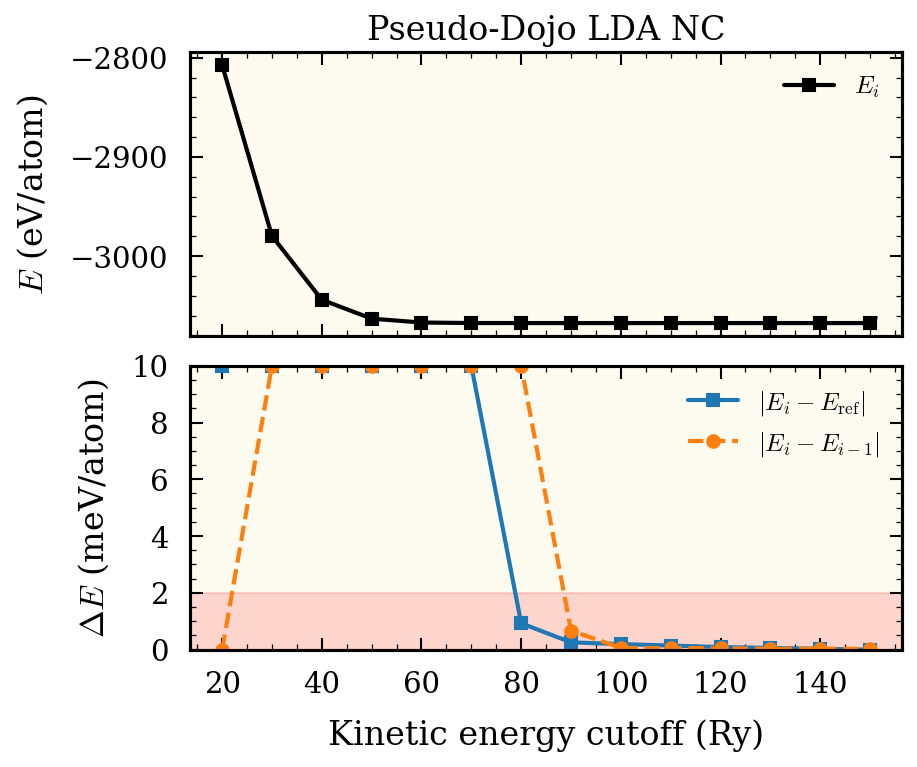

In [5]:
# Pseudo-Dojo LDA

scfs_path = "/home/jvc/ZnO_database/pseudos/ppdojo_LDA/scf_outputs"
data = get_energies(scfs_path)
df_LDA = transform_data_to_df(data)
plot_convergence(df_energies=df_LDA, figure_title="Pseudo-Dojo LDA NC", pdf_fname="ppdojo_ecutconvergence_LDA_NC.pdf")

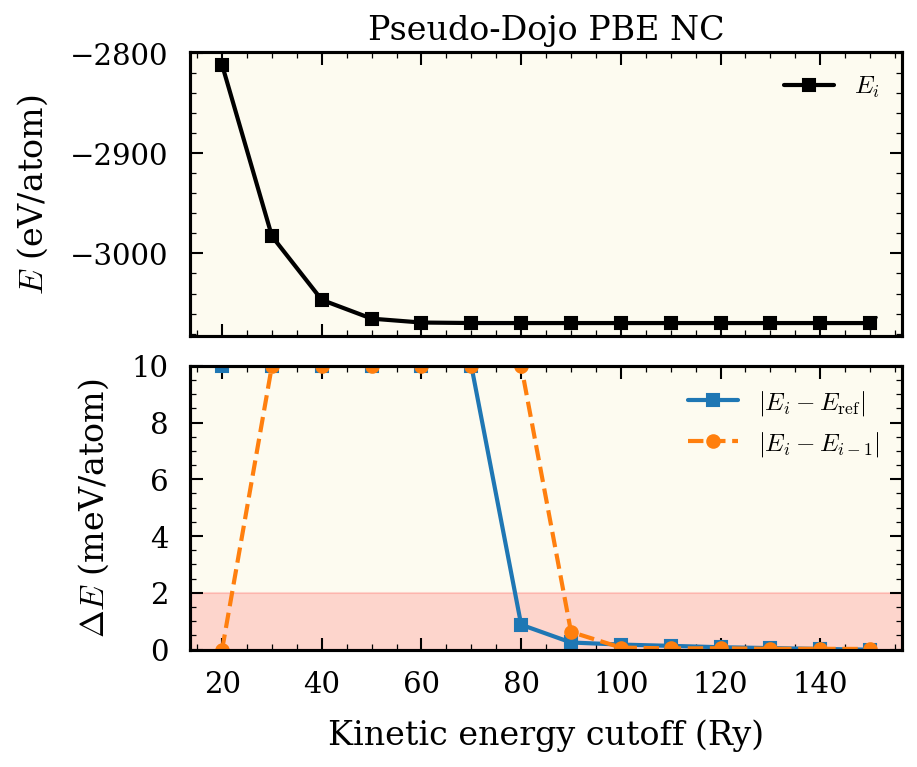

In [6]:
# Pseudo-Dojo PBE
# del scfs_path, data, df

scfs_path = "/home/jvc/ZnO_database/pseudos/ppdojo_PBE/scf_outputs"
data = get_energies(scfs_path)
df_PBE = transform_data_to_df(data)
plot_convergence(df_energies=df_PBE, figure_title="Pseudo-Dojo PBE NC", pdf_fname="ppdojo_ecutconvergence_PBE_NC.pdf")

In [7]:
pd.concat([df_LDA, df_PBE],axis=1)


,File,E/atom,dE_ref_meV,dE_consec_meV,File,E/atom,dE_ref_meV,dE_consec_meV
0,scf_wfc20_rho80.out,-2807.126349,260387.184345,0.000000,scf_wfc20_rho80.out,-2811.666803,257836.153333,0.000000
1,scf_wfc30_rho120.out,-2979.630186,87883.347774,172503.836571,scf_wfc30_rho120.out,-2982.796469,86706.487463,171129.665870
2,scf_wfc40_rho160.out,-3044.031903,23481.630944,64401.716830,scf_wfc40_rho160.out,-3046.353173,23149.782709,63556.704754
3,scf_wfc50_rho200.out,-3063.060702,4452.831705,19028.799238,scf_wfc50_rho200.out,-3065.094254,4408.702052,18741.080657
4,scf_wfc60_rho240.out,-3066.990932,522.601396,3930.230309,scf_wfc60_rho240.out,-3068.984448,518.507817,3890.194234
5,scf_wfc70_rho280.out,-3067.480908,32.626109,489.975287,scf_wfc70_rho280.out,-3069.470710,32.246408,486.261409
6,scf_wfc80_rho320.out,-3067.512604,0.929235,31.696874,scf_wfc80_rho320.out,-3069.502077,0.878758,31.367651
7,scf_wfc90_rho360.out,-3067.513276,0.257148,0.672087,scf_wfc90_rho360.out,-3069.502703,0.253134,0.625624
8,scf_wfc100_rho400.out,-3067.513338,0.195310,0.061838,scf_wfc100_rho400.out,-3069.502777,0.179119,0.074015
9,scf_wfc110_rho440.out,-3067.513389,0.144799,0.050511,scf_wfc110_rho440.out,-3069.502821,0.135173,0.043946


Os gráficos deram os mesmos pelo fato de as energias realmente serem muito próximas.

<h2>Convergência no k-grid</h2>

In [8]:
def get_energies(kpoint_outfiles: str) -> list[list[str, float]]:
    """
    Lê todos os arquivos kpoint.*.out, extrai a energia por átomo em eV.

    Output: [['kpoint*.out', E/atom (eV)], ...]
    """
    NUM_ATOMOS = 4

    files = list(Path(kpoint_outfiles).glob("kpoint*.out"))
    energies = [
        read(f, format="espresso-out").get_total_energy() / NUM_ATOMOS for f in files
    ]

    data: list[list[str, float]] = [[f.name, e] for f, e in zip(files, energies)]
    # Ordem descrescente de energia.
    data.sort(key=lambda x: x[1], reverse=True)
    return data


def transform_data_to_df(data: list) -> pd.DataFrame:
    """
    Cria um DataFrame com informação das energias.
    File	E/atom	dE_ref_meV	dE_consec_meV.

    dE_ref_meV: E_min - E_i
    dE_consec_meV : E_{i+1} - E_{i}
    """

    df = pd.DataFrame(data, columns=["File", "E/atom"])
    df["dE_ref_meV"] = get_deltaEref(df["E/atom"]) * 1_000
    df["dE_consec_meV"] = get_deltaE_consec(df["E/atom"]) * 1_000

    return df


def plot_kgrid_convergence(df: pd.DataFrame, pdf_name: str, figure_title: str):
    """
    Args:
        data: DataFrame with columns: File	E/atom	dE_ref_meV	dE_consec_meV
        pdf_name: name of the output figure file (pdf).
        figure_title: string containing info about selected pseudopotential.
    """
    THR = 2.0  # meV
    YMAX = 10.0  # Limite superior para clipar os valores no gráfico de diferenças.

    kpoints = np.arange(4, 15)

    E_per_atom = df["E/atom"].to_numpy()
    dE_ref_meV = df["dE_ref_meV"].to_numpy()
    dE_consec_meV = df["dE_consec_meV"].to_numpy()

    fig, (axE, axdE) = plt.subplots(
        2,
        1,
        sharex=True,
        figsize=(6, 6),
        dpi=300,
        gridspec_kw={"hspace": 0.05},
        layout="constrained",
    )

    # === Painel (a): energia por átomo vs kgrid ===
    axE.set_title(figure_title)
    axE.set_ylabel(r"$E$ (eV/atom)")
    axE.plot(kpoints, E_per_atom, marker="s", ls="-", color="black", label=r"$E_i$")
    axE.scatter(kpoints[-1], E_per_atom[-1], marker="v", color="black")
    axE.legend()

    # === Painel (b): diferenças em meV/átomo ===

    dE_ref_abs = np.abs(dE_ref_meV)
    dE_consec_abs = np.abs(dE_consec_meV)

    # Versões "clipadas"
    dE_ref_plot = np.clip(dE_ref_abs, 0, YMAX)
    dE_consec_plot = np.clip(dE_consec_abs, 0, YMAX)

    axdE.plot(
        kpoints, dE_ref_plot, marker="s", ls="-", label=r"$|E_i - E_{\mathrm{ref}}|$"
    )
    axdE.plot(kpoints, dE_consec_plot, marker="o", ls="--", label=r"$|E_i - E_{i-1}|$")

    # Faixa de tolerância 0–2 meV/átomo
    axdE.axhspan(0.0, THR, alpha=0.15, color="red")

    axdE.set_ylabel(r"$\Delta E$ (meV/atom)")
    axdE.set_xlabel(r"k-grid", labelpad=10)
    axdE.set_ylim(0, YMAX)

    axdE.legend()

    fig.savefig(pdf_name, bbox_inches="tight")

    plt.show()

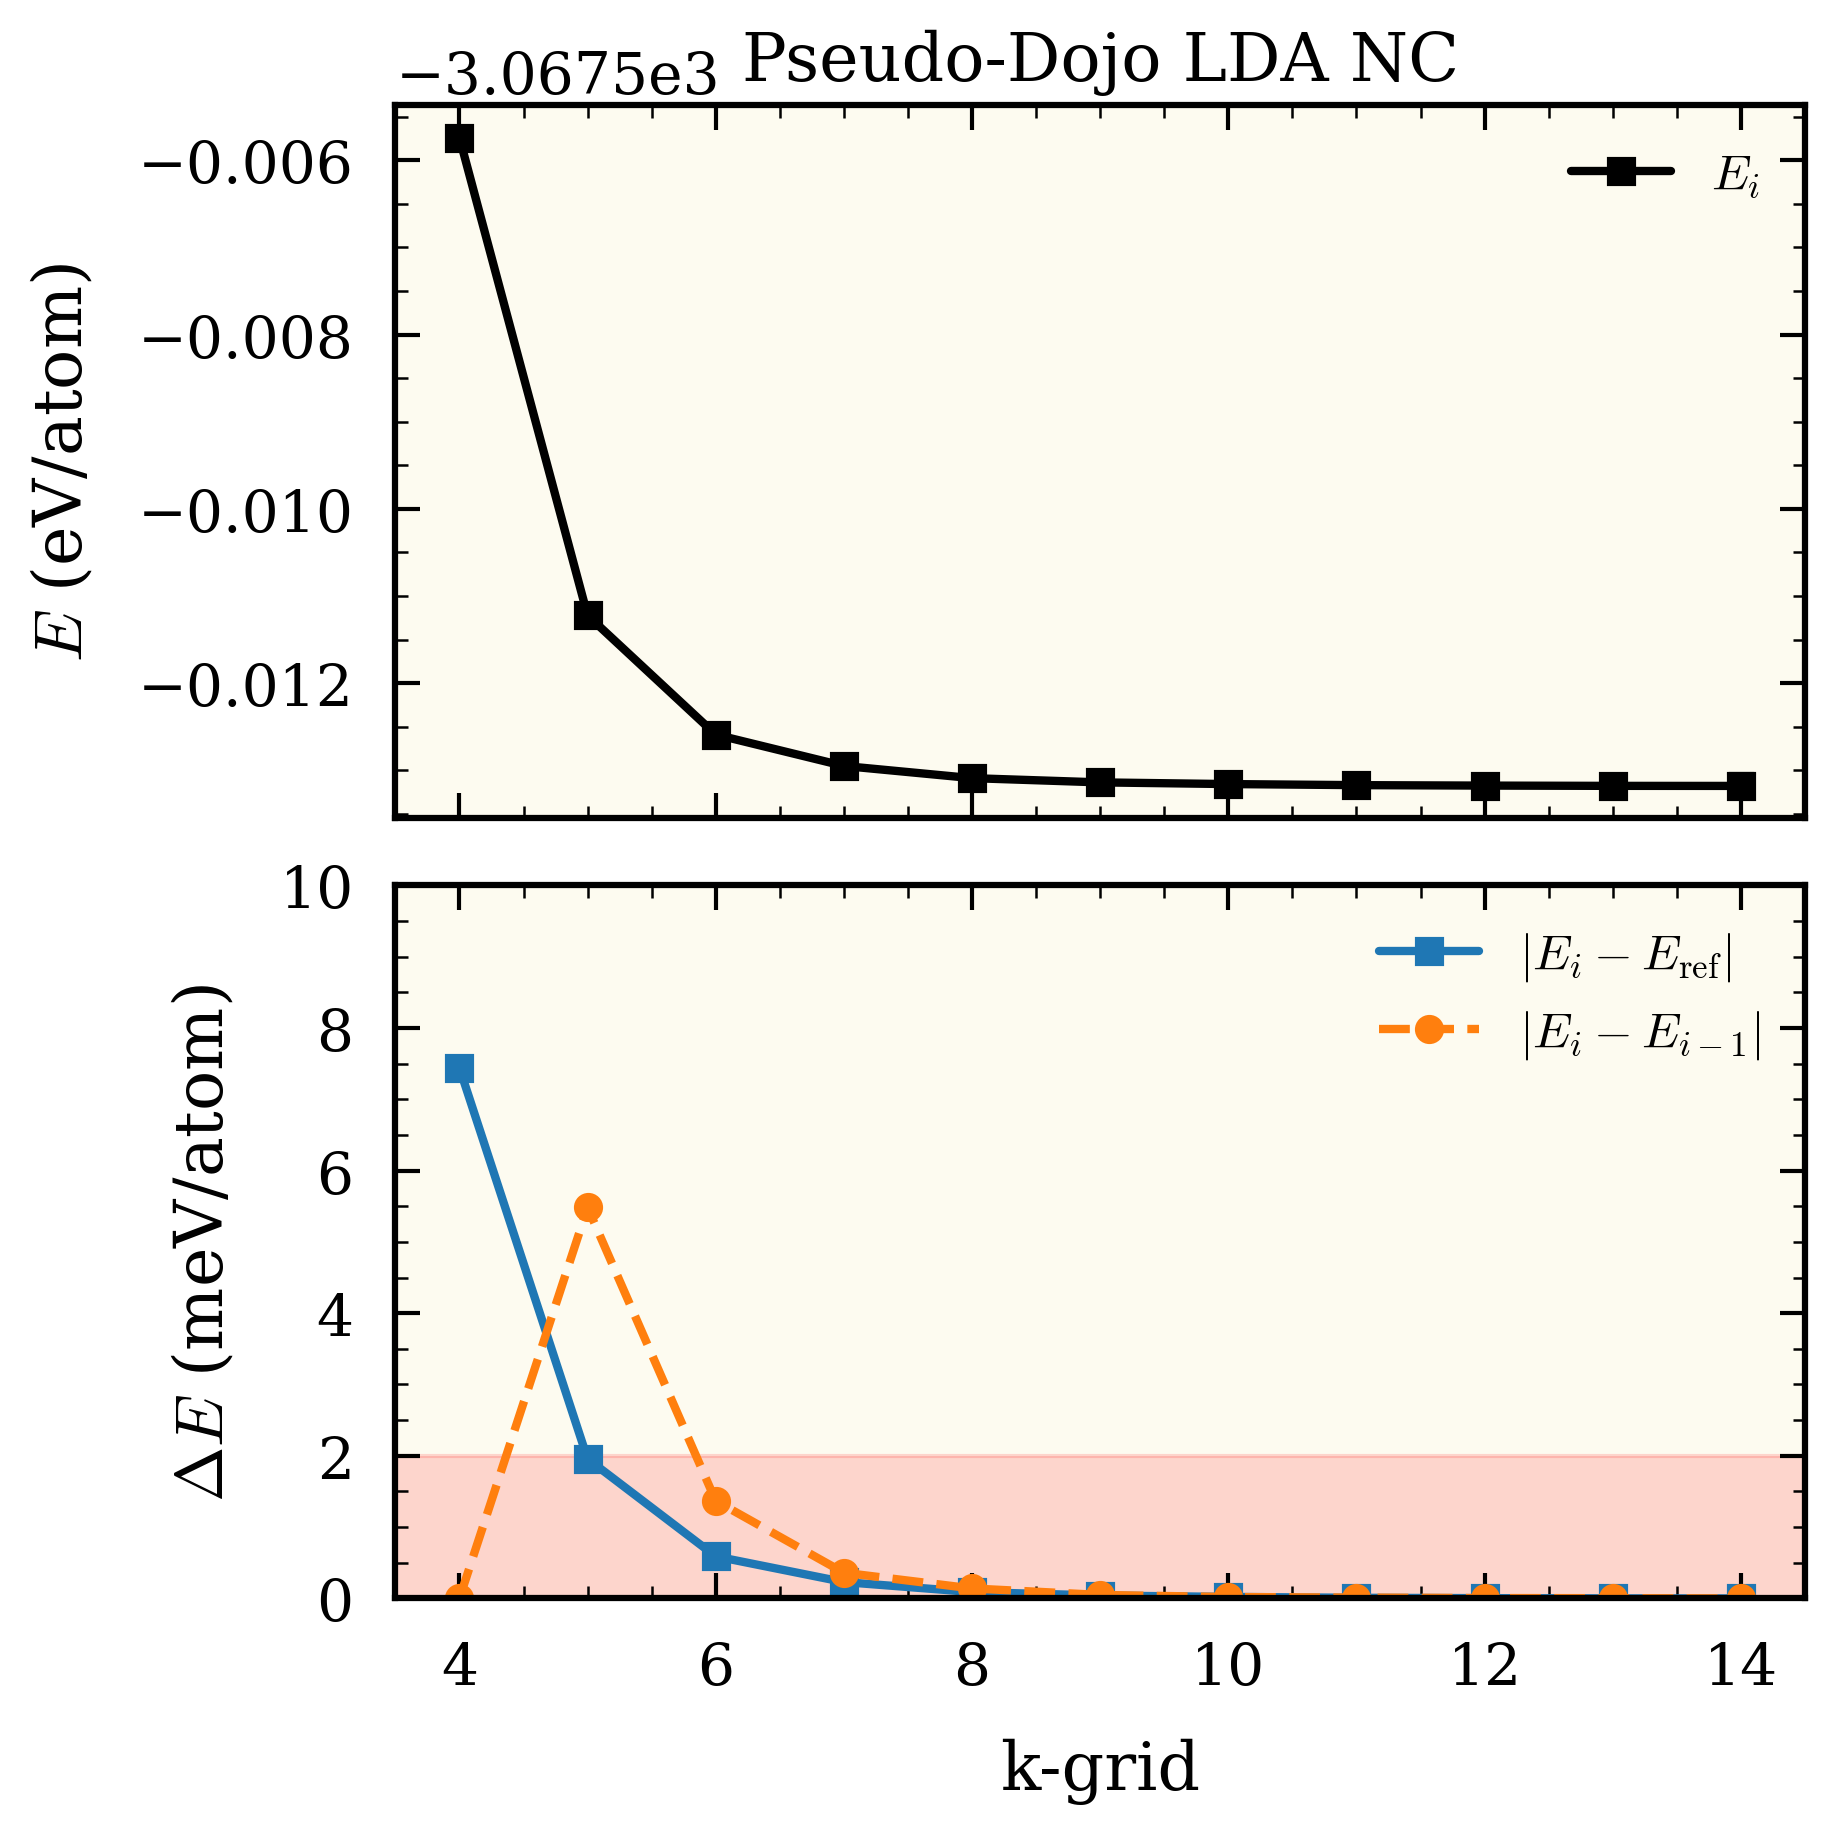

In [13]:
path_to_gallery = "/home/jvc/ZnO_database/gallery"
kpoint_outfiles = "/home/jvc/ZnO_database/pseudos/ppdojo_LDA/kpoints"
data = get_energies(kpoint_outfiles)
df = transform_data_to_df(data)

plot_kgrid_convergence(
    df,
    pdf_name=f"{path_to_gallery}/ppdojo_kgrid_convergence_LDA.pdf",
    figure_title="Pseudo-Dojo LDA NC",
)

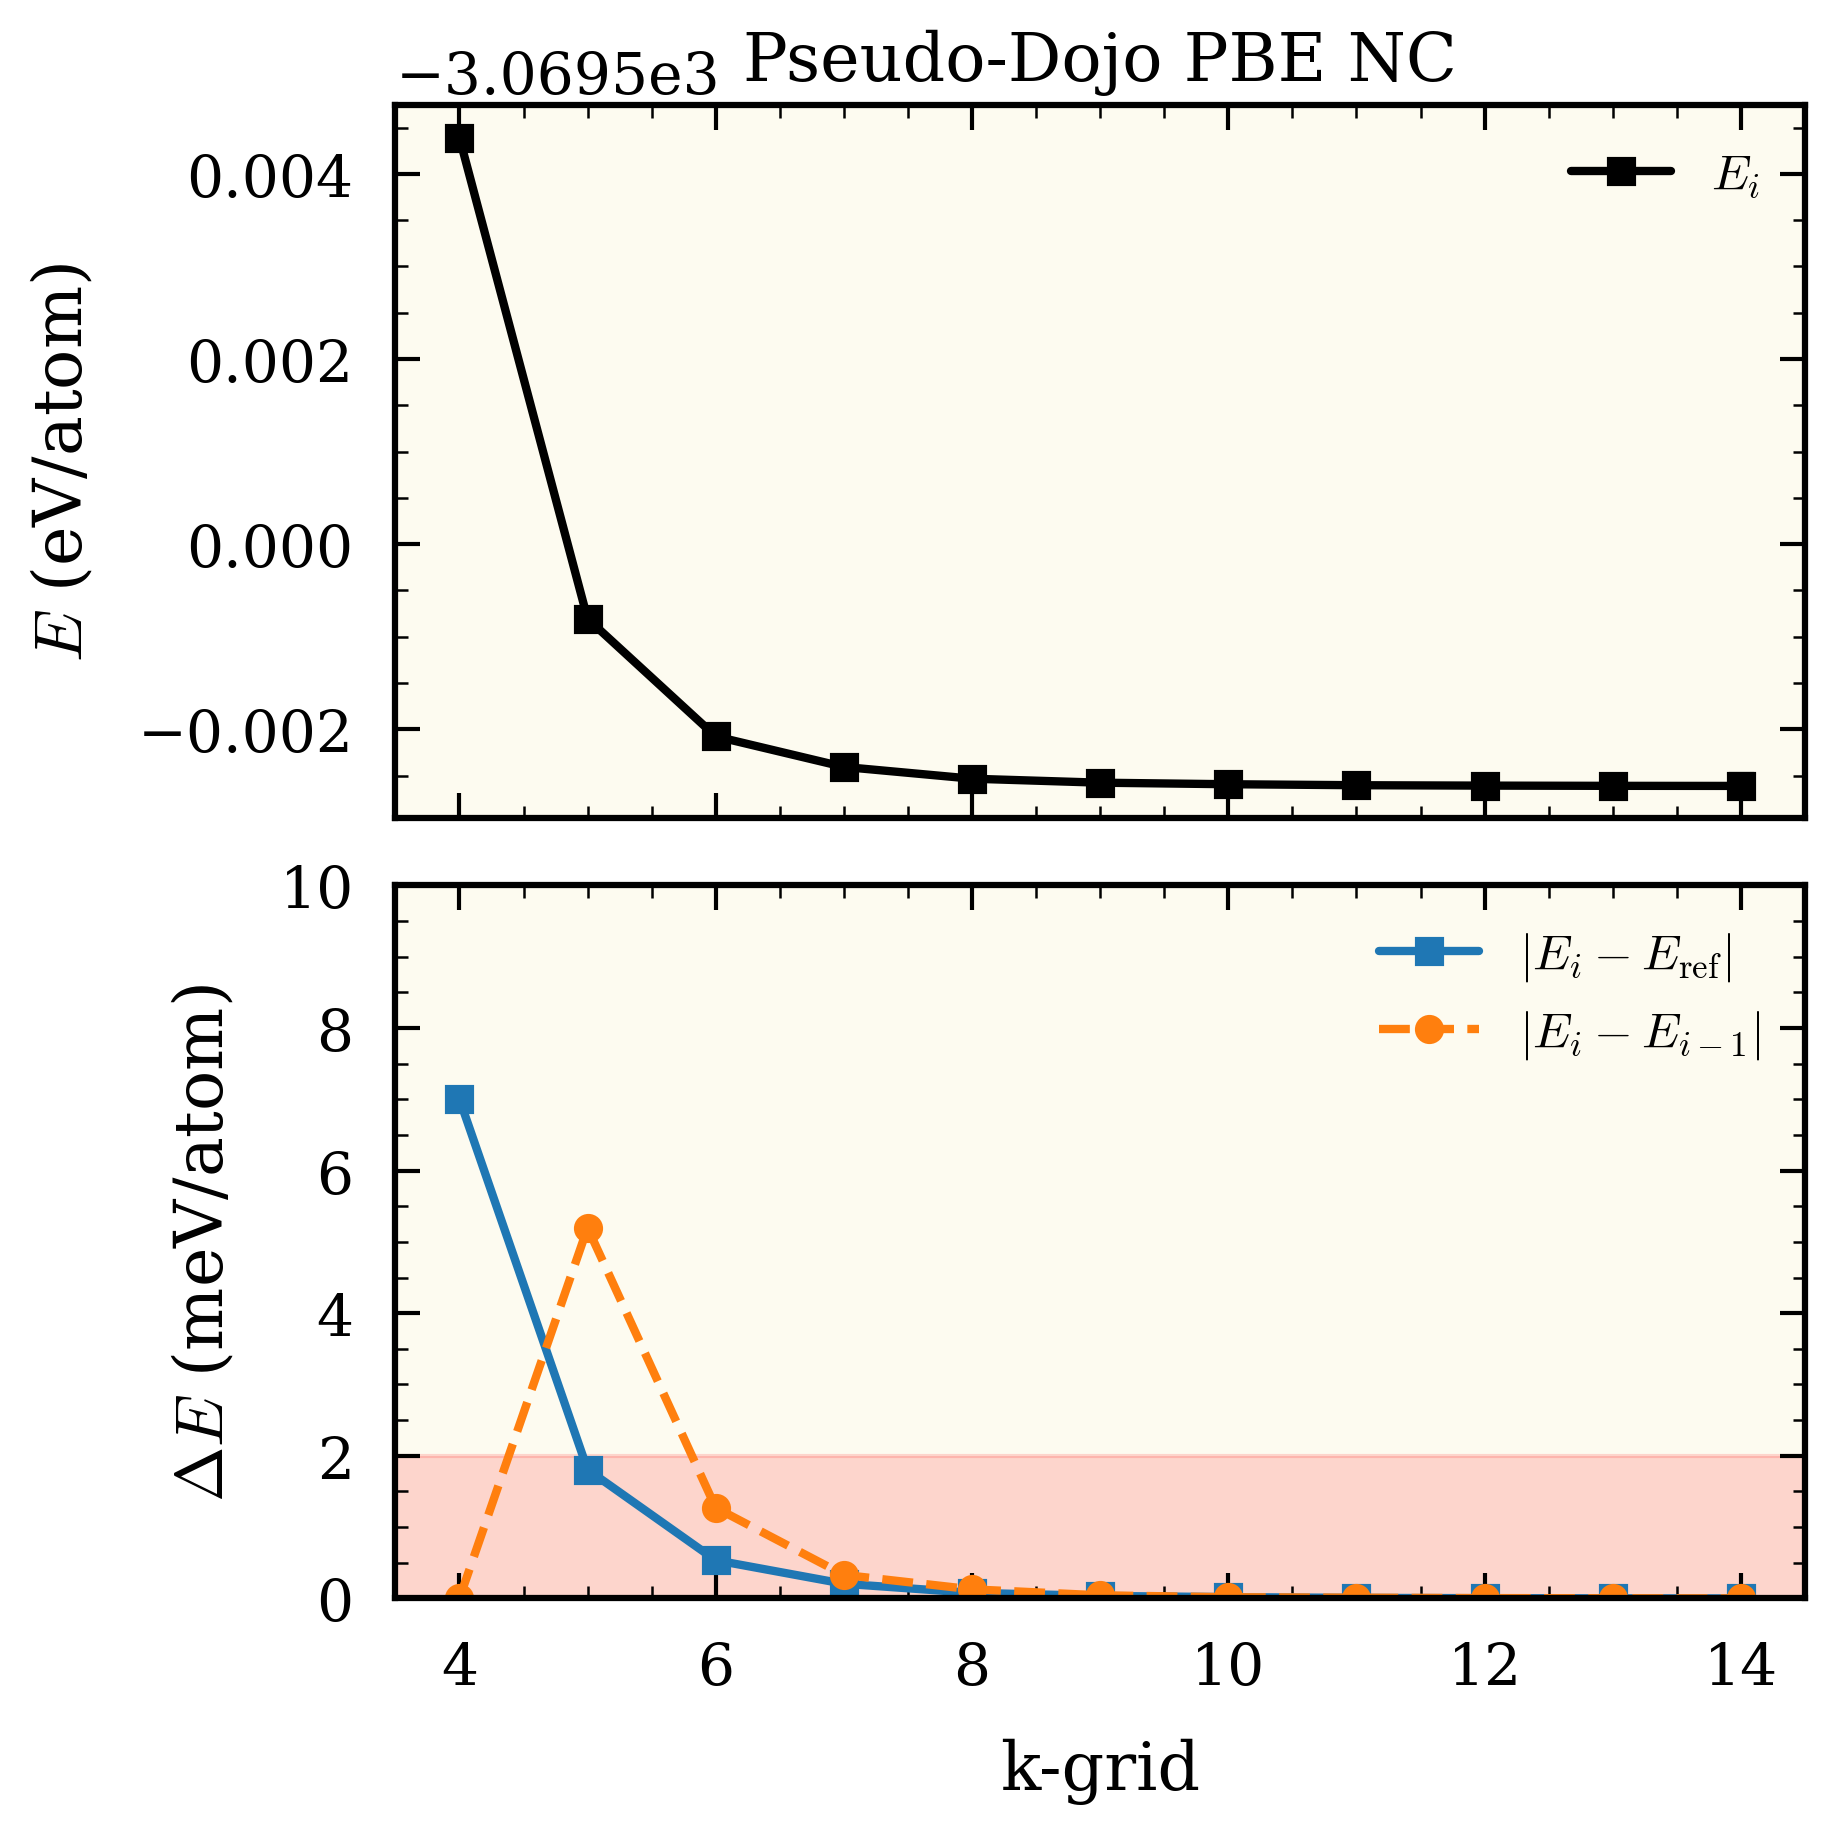

In [10]:
kpoint_outfiles = "/home/jvc/ZnO_database/pseudos/ppdojo_PBE/kpoints/k_outputs"

data = get_energies(kpoint_outfiles)
df = transform_data_to_df(data)

plot_kgrid_convergence(
    df,
    pdf_name="ppdojo_kgrid_convergence_PBE.pdf",
    figure_title="Pseudo-Dojo PBE NC",
)